RB2410 - 收盘价与持仓量相关系数分析
皮尔逊相关系数: -0.1170 (p-value: 0.1070)
斯皮尔曼相关系数: -0.1535 (p-value: 0.0340)
皮尔逊相关强度: 极弱相关或无相关
斯皮尔曼相关强度: 极弱相关或无相关


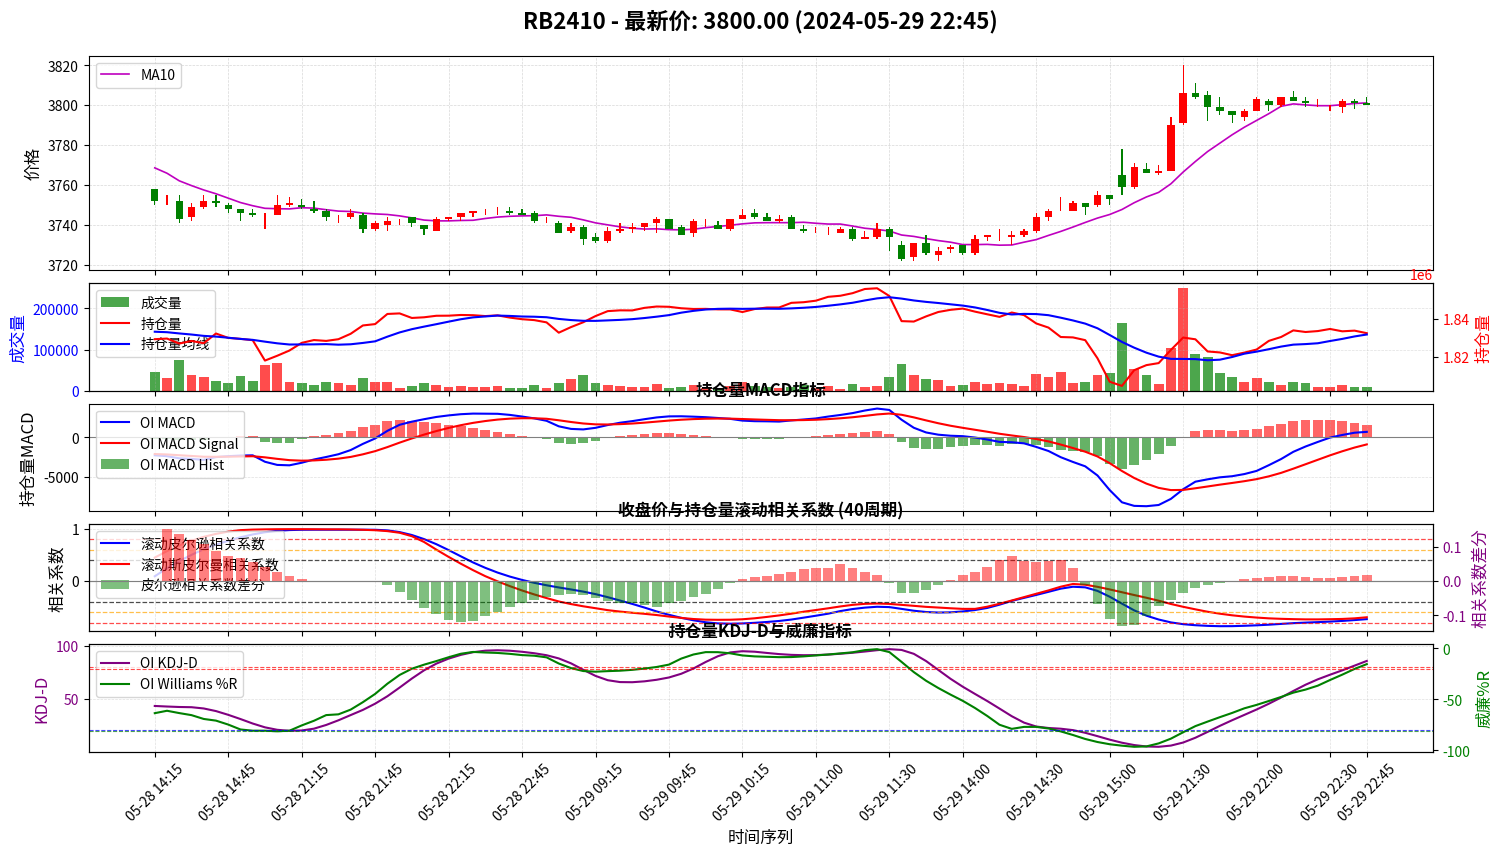

In [1]:
import talib
def jupyter_stock_charts(stock_code, date):
    """Jupyter专用期货合约图表浏览器（带均线、成交量和持仓量技术指标）"""
    
    # 准备数据
    table = get_all_securities(ty='commodity_futures', date=None)
    
    # 获取期货数据
    price_data = get_price_future(
        symbol_list=stock_code,
        end_date=date,
        start_date=None,
        fre_step='5m',
        fields=['open','high','low','close','volume', 'open_interest'],
        fq='pre',
        bar_count=200
    ).sort_index()
    
    if price_data.empty:
        print(f"{stock_code} - 数据获取失败")
        return
    # 计算收盘价和持仓量的相关系数
    
    # 计算均线
    price_data['MA5'] = price_data['close'].rolling(window=5).mean()
    price_data['MA10'] = price_data['close'].rolling(window=10).mean()
    price_data['MA20'] = price_data['close'].rolling(window=20).mean()
    price_data['open_interest_ma'] = price_data['open_interest'].rolling(window=10).mean()
    # 使用TA-Lib计算持仓量的技术指标
    # 1. 持仓量MACD
    macd, macd_signal, macd_hist = talib.MACD(price_data['open_interest'], 
                                             fastperiod=12, slowperiod=26, signalperiod=9)
    price_data['OI_MACD'] = macd
    price_data['OI_MACD_Signal'] = macd_signal
    price_data['OI_MACD_Hist'] = macd_hist
    
    # 2. 持仓量KDJ (使用最高持仓量、最低持仓量、当前持仓量)
    high_oi = price_data['open_interest'].rolling(window=9).max()
    low_oi = price_data['open_interest'].rolling(window=9).min()
    slowk, slowd = talib.STOCH(high_oi, low_oi, price_data['open_interest'],
                              fastk_period=9, slowk_period=3, slowk_matype=0, slowd_period=3, slowd_matype=0)
    price_data['OI_KDJ_K'] = slowk
    price_data['OI_KDJ_D'] = slowd.rolling(window=10).mean()
    price_data['OI_KDJ_J'] = 3 * slowk - 2 * slowd
    
    # 3. 持仓量威廉指标
    willr = talib.WILLR(high_oi, low_oi, price_data['open_interest'], timeperiod=14)
    price_data['OI_Williams'] = willr.rolling(window=10).mean()

    from scipy.stats import pearsonr, spearmanr
    
    # 移除NaN值
    clean_data = price_data[['close', 'open_interest']].rolling(window=10).mean().dropna()
    # 4. 计算滚动相关系数
    price_data['rolling_corr_pearson'] = clean_data['close'].rolling(window=40).corr(clean_data['open_interest'])
    price_data['rolling_corr_spearman'] = clean_data['close'].rolling(window=40).apply(
        lambda x: clean_data.loc[x.index, 'open_interest'].corr(x, method='spearman')
    )
    
    
    if len(clean_data) > 1:
        # 计算皮尔逊相关系数
        pearson_corr, pearson_p = pearsonr(clean_data['close'], clean_data['open_interest'])
        
        # 计算斯皮尔曼相关系数
        spearman_corr, spearman_p = spearmanr(clean_data['close'], clean_data['open_interest'])
        
        # 打印相关系数
        print("=" * 60)
        print(f"{stock_code} - 收盘价与持仓量相关系数分析")
        print("=" * 60)
        print(f"皮尔逊相关系数: {pearson_corr:.4f} (p-value: {pearson_p:.4f})")
        print(f"斯皮尔曼相关系数: {spearman_corr:.4f} (p-value: {spearman_p:.4f})")
        
        # 解释相关系数强度
        def interpret_correlation(corr):
            abs_corr = abs(corr)
            if abs_corr >= 0.8:
                return "极强相关"
            elif abs_corr >= 0.6:
                return "强相关"
            elif abs_corr >= 0.4:
                return "中等相关"
            elif abs_corr >= 0.2:
                return "弱相关"
            else:
                return "极弱相关或无相关"
        
        print(f"皮尔逊相关强度: {interpret_correlation(pearson_corr)}")
        print(f"斯皮尔曼相关强度: {interpret_correlation(spearman_corr)}")
        print("=" * 60)
    else:
        print("数据不足，无法计算相关系数")
    price_data = price_data.tail(100).copy()  # 绘图用最近100个
    # 创建整数索引（去除非交易日间隙）
    price_data['index_num'] = range(len(price_data))
    
    # 创建5个子图
    fig = plt.figure(figsize=(16, 8))
    gs = gridspec.GridSpec(5, 1, height_ratios=[2, 1, 1, 1, 1], hspace=0.1)
    ax1 = plt.subplot(gs[0])  # K线图
    ax2 = plt.subplot(gs[1], sharex=ax1)  # 成交量&持仓量
    ax3 = plt.subplot(gs[2], sharex=ax1)  # 持仓量MACD
    ax4 = plt.subplot(gs[3], sharex=ax1)  # 滚动相关系数
    ax5 = plt.subplot(gs[4], sharex=ax1)  # KDJ-D和威廉指标
    
    # 绘制K线图
    candle_width = 0.6
    up = price_data[price_data.close >= price_data.open]
    down = price_data[price_data.close < price_data.open]
    
    # 上涨K线
    ax1.bar(up['index_num'], up.close - up.open, candle_width, 
           bottom=up.open, color='red', zorder=3, linewidth=0.5)
    ax1.bar(up['index_num'], up.high - up.close, 0.1,
           bottom=up.close, color='red', zorder=3, linewidth=0.5)
    ax1.bar(up['index_num'], up.low - up.open, 0.1, 
           bottom=up.open, color='red', zorder=3, linewidth=0.5)
    
    # 下跌K线
    ax1.bar(down['index_num'], down.close - down.open, candle_width, 
           bottom=down.open, color='green', zorder=3, linewidth=0.5)
    ax1.bar(down['index_num'], down.high - down.open, 0.1, 
           bottom=down.open, color='green', zorder=3, linewidth=0.5)
    ax1.bar(down['index_num'], down.low - down.close, 0.1, 
           bottom=down.close, color='green', zorder=3, linewidth=0.5)
    
    # 绘制均线
    #ax1.plot(price_data['index_num'], price_data['MA5'], 'b-', linewidth=1.2, label='MA5', zorder=2)
    ax1.plot(price_data['index_num'], price_data['MA10'], 'm-', linewidth=1.2, label='MA10', zorder=2)
    #ax1.plot(price_data['index_num'], price_data['MA20'], 'c-', linewidth=1.2, label='MA20', zorder=2)
    
    # 设置K线图标题和标签
    last_close = price_data['close'].iloc[-1]
    last_date = price_data.index[-1].strftime('%Y-%m-%d %H:%M')
    ax1.set_title(f"{stock_code} - 最新价: {last_close:.2f} ({last_date})", 
                 fontsize=16, fontweight='bold', pad=20)
    ax1.set_ylabel('价格', fontsize=12)
    ax1.legend(loc='upper left', fontsize=10)
    ax1.grid(True, linestyle='--', alpha=0.5, linewidth=0.5)
    
    # 第二个子图：成交量&持仓量
    colors_volume = ['red' if close >= open_price else 'green' 
                    for close, open_price in zip(price_data['close'], price_data['open'])]
    ax2.bar(price_data['index_num'], price_data['volume'], color=colors_volume, width=0.8, 
            linewidth=0.5, alpha=0.7, label='成交量')
    ax2.set_ylabel('成交量', fontsize=12, color='blue')
    ax2.tick_params(axis='y', labelcolor='blue')
    
    # 创建右侧y轴用于持仓量
    ax2_right = ax2.twinx()
    ax2_right.plot(price_data['index_num'], price_data['open_interest'], 'r-', 
                  linewidth=1.5, label='持仓量')
    ax2_right.plot(price_data['index_num'], price_data['open_interest_ma'], 'b-', 
                  linewidth=1.5, label='持仓量均线')
    ax2_right.set_ylabel('持仓量', fontsize=12, color='red')
    ax2_right.tick_params(axis='y', labelcolor='red')
    
    # 设置成交量&持仓量图的网格
    ax2.grid(True, linestyle='--', alpha=0.4, linewidth=0.5)
    
    # 合并图例
    lines1, labels1 = ax2.get_legend_handles_labels()
    lines2, labels2 = ax2_right.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)
    
    # 第三个子图：持仓量MACD
    ax3.plot(price_data['index_num'], price_data['OI_MACD'], 'b-', linewidth=1.5, label='OI MACD')
    ax3.plot(price_data['index_num'], price_data['OI_MACD_Signal'], 'r-', linewidth=1.5, label='OI MACD Signal')
    # 绘制MACD柱状图
    colors_macd = ['red' if x >= 0 else 'green' for x in price_data['OI_MACD_Hist']]
    ax3.bar(price_data['index_num'], price_data['OI_MACD_Hist'], color=colors_macd, 
            width=0.8, alpha=0.6, label='OI MACD Hist')
    ax3.set_ylabel('持仓量MACD', fontsize=12)
    ax3.axhline(0, color='gray', linestyle='-', linewidth=0.8)
    ax3.legend(loc='upper left', fontsize=10)
    ax3.grid(True, linestyle='--', alpha=0.4, linewidth=0.5)
    ax3.set_title('持仓量MACD指标', fontsize=12, fontweight='bold')
    
    # 第四个子图：滚动相关系数
    # 计算皮尔逊相关系数的差分
    price_data['rolling_corr_pearson_diff'] = price_data['rolling_corr_pearson'].diff()
    
    # 创建右侧y轴用于皮尔逊相关系数差分
    ax4_right = ax4.twinx()
    
    # 绘制差分柱状图，使用不同颜色表示正负值
    colors_diff = ['red' if x >= 0 else 'green' for x in price_data['rolling_corr_pearson_diff']]
    ax4_right.bar(price_data['index_num'], price_data['rolling_corr_pearson_diff'], 
                  color=colors_diff, width=0.8, alpha=0.5, label='皮尔逊相关系数差分')
    ax4_right.set_ylabel('相关系数差分', fontsize=12, color='purple')
    ax4_right.tick_params(axis='y', labelcolor='purple')
    ax4_right.axhline(0, color='gray', linestyle='-', linewidth=0.8)
    
    # 绘制滚动相关系数线图
    ax4.plot(price_data['index_num'], price_data['rolling_corr_pearson'], 'b-', 
             linewidth=1.5, label='滚动皮尔逊相关系数')
    ax4.plot(price_data['index_num'], price_data['rolling_corr_spearman'], 'r-', 
             linewidth=1.5, label='滚动斯皮尔曼相关系数')
    ax4.set_ylabel('相关系数', fontsize=12)
    
    # 动态设置Y轴范围，确保充分显示相关系数曲线
    corr_min = min(price_data['rolling_corr_pearson'].min(), price_data['rolling_corr_spearman'].min())
    corr_max = max(price_data['rolling_corr_pearson'].max(), price_data['rolling_corr_spearman'].max())
    margin = max(abs(corr_min), abs(corr_max)) * 0.1  # 使用10%的边距
    ax4.set_ylim(corr_min - margin, corr_max + margin)
    
    ax4.axhline(0, color='gray', linestyle='-', linewidth=0.8)
    ax4.legend(loc='upper left', fontsize=10)
    ax4.grid(True, linestyle='--', alpha=0.4, linewidth=0.5)
    ax4.set_title('收盘价与持仓量滚动相关系数 (40周期)', fontsize=12, fontweight='bold')
    
    # 添加相关系数参考线
    ax4.axhline(0.8, color='red', linestyle='--', linewidth=0.9, alpha=0.7)
    ax4.axhline(0.6, color='orange', linestyle='--', linewidth=0.9, alpha=0.7)
    ax4.axhline(0.4, color='black', linestyle='--', linewidth=0.9, alpha=0.7)
    ax4.axhline(-0.8, color='red', linestyle='--', linewidth=0.9, alpha=0.7)
    ax4.axhline(-0.6, color='orange', linestyle='--', linewidth=0.9, alpha=0.7)
    ax4.axhline(-0.4, color='black', linestyle='--', linewidth=0.9, alpha=0.7)
    
    # 合并图例
    lines4, labels4 = ax4.get_legend_handles_labels()
    lines4_right, labels4_right = ax4_right.get_legend_handles_labels()
    ax4.legend(lines4 + lines4_right, labels4 + labels4_right, loc='upper left', fontsize=10)
    
    # 第五个子图：KDJ-D和威廉指标
    # 绘制KDJ-D线
    ax5.plot(price_data['index_num'], price_data['OI_KDJ_D'], 'purple', 
             linewidth=1.5, label='OI KDJ-D')
    ax5.set_ylabel('KDJ-D', fontsize=12, color='purple')
    ax5.tick_params(axis='y', labelcolor='purple')
    
    # 创建右侧y轴用于威廉指标
    ax5_right = ax5.twinx()
    ax5_right.plot(price_data['index_num'], price_data['OI_Williams'], 'g-', 
             linewidth=1.5, label='OI Williams %R')
    ax5_right.set_ylabel('威廉%R', fontsize=12, color='green')
    ax5_right.tick_params(axis='y', labelcolor='green')
    
    # 设置网格和标签
    ax5.grid(True, linestyle='--', alpha=0.4, linewidth=0.5)
    ax5.set_xlabel('时间序列', fontsize=12)
    ax5.set_title('持仓量KDJ-D与威廉指标', fontsize=12, fontweight='bold')
    
    # 添加KDJ-D参考线
    ax5.axhline(80, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
    ax5.axhline(20, color='green', linestyle='--', linewidth=0.8, alpha=0.7)
    
    # 添加威廉指标参考线
    ax5_right.axhline(-20, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
    ax5_right.axhline(-80, color='blue', linestyle='--', linewidth=0.8, alpha=0.7)
    
    # 合并图例
    lines3, labels3 = ax5.get_legend_handles_labels()
    lines4, labels4 = ax5_right.get_legend_handles_labels()
    ax5.legend(lines3 + lines4, labels3 + labels4, loc='upper left', fontsize=10)
    
    # 设置x轴刻度
    n = len(price_data)
    step = max(1, n // 15)
    xticks = list(range(0, n, step))
    if n-1 not in xticks:
        xticks.append(n-1)
    xticklabels = [price_data.index[i].strftime('%m-%d %H:%M') for i in xticks]
    ax5.set_xticks(xticks)
    ax5.set_xticklabels(xticklabels, rotation=45, fontsize=10)
    
    # 设置K线图y轴范围
    y_min = price_data[['low', 'MA5', 'MA10', 'MA20']].min().min()
    y_max = price_data[['high', 'MA5', 'MA10', 'MA20']].max().max()
    margin = (y_max - y_min) * 0.05
    ax1.set_ylim(y_min - margin, y_max + margin)
    
    # 隐藏上方子图的x轴标签
    plt.setp(ax1.get_xticklabels(), visible=False)
    plt.setp(ax2.get_xticklabels(), visible=False)
    plt.setp(ax3.get_xticklabels(), visible=False)
    plt.setp(ax4.get_xticklabels(), visible=False)
    
    # 调整子图间距
    plt.subplots_adjust(top=0.95, bottom=0.08, left=0.08, right=0.92)
    
    plt.tight_layout()
    plt.show()

    
import matplotlib.gridspec as gridspec
import datetime
import matplotlib.pyplot as plt

# 使用示例
jupyter_stock_charts('RB2410', '20240529 22:45')